# Fetching Gold/USD Price Data

This notebook demonstrates how to fetch historical and real-time Gold/USD price data using Yahoo Finance via the yfinance library.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Fetch historical daily Gold/USD data (last 1 year)
gold = yf.Ticker("GC=F")
daily_data = gold.history(period="1y")

print(daily_data.tail())

                                  Open         High          Low        Close  \
Date                                                                            
2026-04-07 00:00:00-04:00  4624.899902  4676.299805  4608.000000  4657.100098   
2026-04-08 00:00:00-04:00  4760.000000  4851.000000  4738.799805  4749.500000   
2026-04-09 00:00:00-04:00  4711.000000  4799.100098  4711.000000  4792.200195   
2026-04-10 00:00:00-04:00  4745.899902  4791.000000  4744.899902  4761.899902   
2026-04-13 00:00:00-04:00  4710.000000  4761.100098  4626.000000  4751.399902   

                           Volume  Dividends  Stock Splits  
Date                                                        
2026-04-07 00:00:00-04:00     327        0.0           0.0  
2026-04-08 00:00:00-04:00     405        0.0           0.0  
2026-04-09 00:00:00-04:00    1277        0.0           0.0  
2026-04-10 00:00:00-04:00    1277        0.0           0.0  
2026-04-13 00:00:00-04:00   41334        0.0           0.0  


In [3]:
# Fetch historical hourly Gold/USD data (last 7 days)
hourly_data = gold.history(period="7d", interval="1h")

print(hourly_data.tail())

                                  Open         High          Low        Close  \
Datetime                                                                        
2026-04-12 23:00:00-04:00  4742.500000  4745.799805  4733.700195  4741.600098   
2026-04-13 00:00:00-04:00  4740.000000  4747.000000  4729.200195  4744.700195   
2026-04-13 01:00:00-04:00  4744.899902  4752.600098  4737.899902  4751.100098   
2026-04-13 02:00:00-04:00  4751.500000  4754.700195  4742.700195  4747.899902   
2026-04-13 03:00:00-04:00  4748.000000  4761.100098  4747.399902  4752.000000   

                           Volume  Dividends  Stock Splits  
Datetime                                                    
2026-04-12 23:00:00-04:00    1479        0.0           0.0  
2026-04-13 00:00:00-04:00    2617        0.0           0.0  
2026-04-13 01:00:00-04:00    2387        0.0           0.0  
2026-04-13 02:00:00-04:00    3468        0.0           0.0  
2026-04-13 03:00:00-04:00    1865        0.0           0.0  


In [4]:
# Fetch real-time (latest) Gold/USD price
latest_data = gold.history(period="1d")
latest_price = latest_data['Close'].iloc[-1]
print(f"Latest Gold/USD price: ${latest_price:.2f}")

Latest Gold/USD price: $4751.40


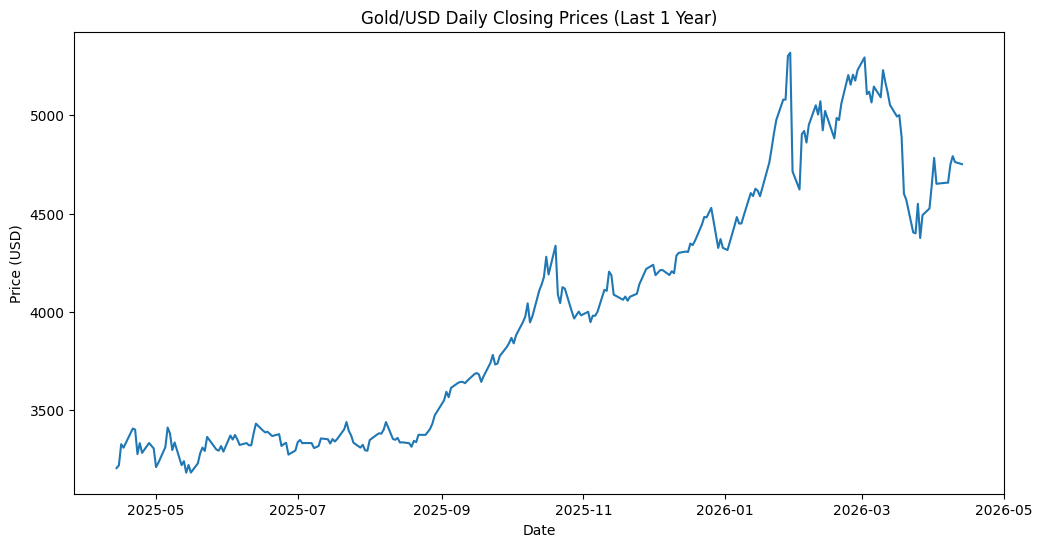

In [5]:
# Plot the daily closing prices
plt.figure(figsize=(12,6))
plt.plot(daily_data.index, daily_data['Close'])
plt.title('Gold/USD Daily Closing Prices (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

# Machine Learning Model for Gold/USD Price Prediction

We will develop an LSTM neural network to predict future Gold/USD prices based on historical data. LSTM is suitable for time series forecasting as it can capture long-term dependencies.

In [6]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import mlflow
import mlflow.keras
import mlflow.sklearn
import mlflow.pyfunc

In [7]:
# Prepare data for LSTM
data = daily_data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days to predict next
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:
# Set up MLflow experiment
import mlflow
mlflow.set_experiment("Gold Price Prediction")

<Experiment: artifact_location='file:///c:/Ironhack/Capstone%202/mlruns/733085135171792030', creation_time=1775812717538, experiment_id='733085135171792030', last_update_time=1775812717538, lifecycle_stage='active', name='Gold Price Prediction', tags={}>

In [9]:
# Build LSTM model
with mlflow.start_run(run_name="LSTM"):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=0)

    # Log parameters
    mlflow.log_param("seq_length", seq_length)
    mlflow.log_param("epochs", 10)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("units", 50)
    mlflow.log_param("dropout", 0.2)

    # Predictions and metrics
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    # y_test_actual = scaler.inverse_transform(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mlflow.log_metric("rmse", rmse)

    # Log model
    mlflow.keras.log_model(model, "model")

print(f'LSTM RMSE: {rmse}')


c:\Ironhack\Capstone 2\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


2026/04/13 09:38:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 09:38:06 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/13 09:38:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LSTM RMSE: 280.84468565380325


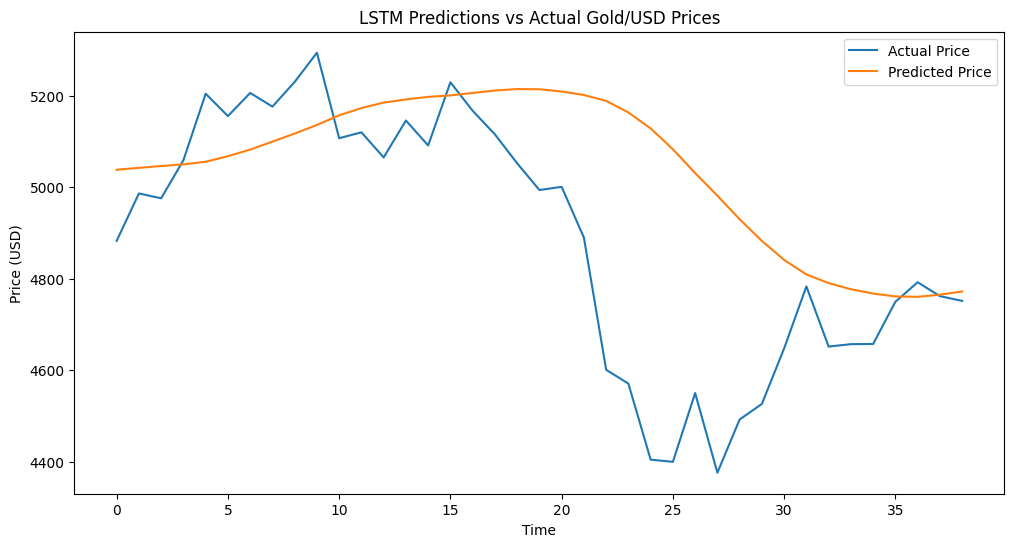

In [10]:
# Plot predictions vs actual (LSTM is already logged above)
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('LSTM Predictions vs Actual Gold/USD Prices')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## ARIMA Model

As an alternative, we can use an ARIMA model for time series forecasting.

In [11]:
# ARIMA model
with mlflow.start_run(run_name="ARIMA"):
    train_arima = daily_data['Close'][:-30]
    test_arima = daily_data['Close'][-30:]

    model_arima = ARIMA(train_arima, order=(5,1,0))
    model_arima_fit = model_arima.fit()

    forecast = model_arima_fit.forecast(steps=30)
    rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast))

    # Log parameters and metrics
    mlflow.log_param("order", (5,1,0))
    mlflow.log_metric("rmse", rmse_arima)

    # Note: Model logging for ARIMA is skipped to avoid complexity

print(f'ARIMA RMSE: {rmse_arima}')


ARIMA RMSE: 480.55287896353195


c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_predic

## Neural network


In [12]:
# Neural Network model (MLPRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.metrics import mean_squared_error
import mlflow
import mlflow.sklearn

# Prepare data with lags
data = daily_data['Close'].values
LAGS = 5
X, y = [], []
for i in range(LAGS, len(data)):
    X.append(data[i - LAGS:i])
    y.append(data[i])
X = np.array(X)
y = np.array(y)

# Train/test split
test_size = 30
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model_nn = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)

with mlflow.start_run(run_name="Neural_Network_MLP"):
    model_nn.fit(X_train_scaled, y_train)
    
    preds_test = model_nn.predict(X_test_scaled)
    rmse_nn = np.sqrt(mean_squared_error(y_test, preds_test))
    
    # Log parameters and metrics
    mlflow.log_param("hidden_layer_sizes", (50, 50))
    mlflow.log_param("lags", LAGS)
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("rmse", rmse_nn)
    
    mlflow.sklearn.log_model(model_nn, artifact_path="model")
    
print(f'Neural Network RMSE: {rmse_nn}')

c:\Ironhack\Capstone 2\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/04/13 09:38:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 09:38:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Neural Network RMSE: 587.6157347396295


## Linear Regression Model

As another approach, we can use linear regression with lagged features for prediction.

In [15]:
import numpy as np
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =============================
# CONFIG
# =============================
EXPERIMENT_NAME = "Gold Price Prediction"
LAGS = 5

mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.end_run()

# =============================
# LOAD DATA (replace with your real data)
# =============================
# data = your time series list/array
data = np.array(data, dtype=float).flatten()

# =============================
# CREATE LAG FEATURES
# =============================
X, y = [], []

for i in range(LAGS, len(data)):
    X.append(data[i - LAGS:i])
    y.append(data[i])

X = np.array(X)
y = np.array(y)

# =============================
# TRAIN/TEST SPLIT
# =============================
test_size = 30

X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# =============================
# MODEL PIPELINE
# =============================
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LinearRegression())
])

with mlflow.start_run(run_name="linear_regression_5_lags"):

    pipeline.fit(X_train, y_train)

    preds_train = pipeline.predict(X_train)
    preds_test = pipeline.predict(X_test)

    mse_test = mean_squared_error(y_test, preds_test)
    rmse_reg = np.sqrt(mse_test)
    r2_test = r2_score(y_test, preds_test)

    mlflow.log_param("lags", LAGS)
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("mse_test", mse_test)
    mlflow.log_metric("rmse", rmse_reg)
    mlflow.log_metric("r2_test", r2_test)

    mlflow.sklearn.log_model(
        pipeline,
        artifact_path="model",
        input_example=X_train[:1]
    )

    print("Training complete")



2026/04/13 09:40:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training complete


## Model Evaluation and Comparison

Compare the RMSE values of the four models: LSTM, ARIMA, Neural Network, and Linear Regression.

In [17]:
# Model Comparison
print("Model Performance Comparison:")
print(f"LSTM RMSE: {rmse}")
print(f"ARIMA RMSE: {rmse_arima}")
print(f"Neural Network RMSE: {rmse_nn}")
print(f"Linear Regression RMSE: {rmse_reg}")

# Determine the best model
rmses = {'LSTM': rmse, 'ARIMA': rmse_arima, 'Neural Network': rmse_nn, 'Linear Regression': rmse_reg}
best_model = min(rmses, key=rmses.get)
print(f"\nBest performing model: {best_model} with RMSE {rmses[best_model]}")

Model Performance Comparison:
LSTM RMSE: 280.84468565380325
ARIMA RMSE: 480.55287896353195
Neural Network RMSE: 587.6157347396295
Linear Regression RMSE: 119.92586786615173

Best performing model: Linear Regression with RMSE 119.92586786615173


In [ ]:
runs = mlflow.search_runs()

for _, r in runs.iterrows():
    print(f"Run ID: {r['run_id']}, Name: {r['tags.mlflow.runName']}, RMSE: {r['metrics.rmse']}")

Run ID: b7c9a82aabd744108cec7bcf2b7ef885, Name: LinearRegression, RMSE: 118.9832795821916
Run ID: dd3e8c29160943069892890e93884337, Name: LinearRegression, RMSE: 118.9832795821916
Run ID: 1a9be61caf9b4e759c49d58617fc8d61, Name: ARIMA, RMSE: 434.4548086954244
Run ID: 2487997dd2e14738ad5acde099d2358e, Name: LSTM, RMSE: 387.48519353729006
Run ID: 392790ef10ac4d1491f41c41ae0d2776, Name: LinearRegression, RMSE: 118.95721702164012
Run ID: b4ac6e8e3e0c4e6f8495215ac48bad53, Name: LinearRegression, RMSE: 118.95721702164012
Run ID: bcfe9f31f4474426a6f4522730788d7a, Name: ARIMA, RMSE: 434.26825532317173
Run ID: 03cc65b0a6e14561b7b07d96e6c92d88, Name: LSTM, RMSE: 337.117664557428
Run ID: 1001844aba8d4c7289c175d426b4d743, Name: LinearRegression, RMSE: 118.98693514682711
Run ID: 0a7e8d1c2b044101a604c7794d8c4266, Name: ARIMA, RMSE: 434.47638454986867
Run ID: 0b27a8f2d73142cda348c32097882a0a, Name: LSTM, RMSE: 390.09927971772197
Run ID: ad287ef0fee14d0abc7cf2e0f5781fb5, Name: LSTM, RMSE: nan
Run ID: c

# REST API with FastAPI

A FastAPI application has been created in `api.py` to serve predictions from the Linear Regression model.

To run the API:
1. Open a terminal and navigate to the project directory.
2. Run `python main.py`
3. The API will be available at http://localhost:8000.
4. Use the `/docs` endpoint for interactive documentation.

Example request:
```json
{
  "prices": [2000.0, 2010.0, 1995.0, 2020.0, 2015.0]
}
```

This will return the predicted next day's price.